## Imports


In [15]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import csv
import json
import random
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
from pprint import pprint, pformat

import numpy as np
import jax
import matplotlib.pyplot as plt
from tqdm.auto import trange

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.sampling import Sampling
from pymoo.core.repair import Repair
from pymoo.core.variable import Real, Integer, Binary
from pymoo.core.mixed import MixedVariableMating, MixedVariableDuplicateElimination
from pymoo.algorithms.moo.sms import SMSEMOA, cv_and_dom_tournament
from pymoo.algorithms.moo.nsga2 import NSGA2, binary_tournament
from pymoo.operators.mutation.pm import PM
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize

from LINKS.Optimization import Tools, DifferentiableTools, MechanismRandomizer
from LINKS.Geometry import CurveEngine
from LINKS.Visualization import MechanismVisualizer
from LINKS.CP import REFERENCE_POINTS, MAX_JOINTS, make_empty_submission, evaluate_submission

import pymoo
print("pymoo version:", pymoo.__version__)

from collections import OrderedDict
from bisect import bisect_left
from pymoo.operators.selection.tournament import TournamentSelection

pymoo version: 0.6.1


## Settings


In [50]:
# Open this notebook in the repository containing LINKS, utils, and the .npy files.
TARGET_PATH = Path('kangaroo_target_curves.npy')
ALGORITHMS = ('SMS_EMOA',)
TARGET_INDICES = (0,1,2)       # Compare Curve 1 first; (0, 1, 2) compares all curves.
QUICK_CHECK = False
JOINT_COUNTS = (5, 6,7,11)
SEEDS = (3407,)
COORDINATE_BOUNDS = (0.0, 5.0)

POPULATION_SIZES = (100,)
# The same evaluation budgets apply to EVERY population and joint count.
GA1_EVALUATIONS = 600 if QUICK_CHECK else 4800
GA2_EVALUATIONS = 300 if QUICK_CHECK else 2400
CASE_CONFIGS = tuple(dict(name=f'{a}_P{p}', algorithm=a, population=p)
                     for a in ALGORITHMS for p in POPULATION_SIZES)
CASE_NAMES = tuple(c['name'] for c in CASE_CONFIGS)
DISTANCE_WEIGHTS = (0.50, 0.95)
GD_STEPS = 5 if QUICK_CHECK else 80
MAX_GD_CANDIDATES = 2 if QUICK_CHECK else 4
GD_LEARNING_RATE = 4e-4
GD_MAX_BACKTRACKS = 6
GD_MAX_COORDINATE_STEP = 0.02
GD_MIN_IMPROVEMENT = 1e-10

RUN_FINAL_REFINEMENT = True
FINAL_GD_CANDIDATES = 2 if QUICK_CHECK else 4
FINAL_GD_STEPS = 3 if QUICK_CHECK else 15
HV_MIN_GAIN = 1e-10       # Raw HV; accept final-polish steps only above this gain.
STAGE1_MUTATION = (0.90, 0.30, 0.02)
STAGE2_MUTATION = (0.30, 0.15, 0.01)
MUTATION_ETA = 20
MATING_MAX_ITERATIONS = 20
MAX_SUBMITTED_DESIGNS = 1000
OBJECTIVE_CACHE_SIZE = 10000
SHOW_FINAL_CURVE = True
VERBOSE = False

# Cutoffs remain disabled to compare equal GA budgets.
MIN_GA1_HV = {0: None, 1: None, 2: None}  # Disabled for the controlled comparison.
SKIP_IF_NO_FEASIBLE = False  # GA2 gets its budget even if GA1 has no feasible designs.
# Optional trusted full submission files from previous runs; re-scored before reuse.
WARM_START_FILES = ()
# Example: WARM_START_FILES = (r'BC_DS_JC_results/old_run/my_full_submission.npy',)
# Extra official evaluations cost time; the combined final file is always evaluated.
SCORE_EACH_ALGORITHM = True

RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR = Path('BC_DS_JC_Population_Comparison_results') / RUN_ID
ACTIVE_JOINT_COUNTS = JOINT_COUNTS
ACTIVE_SEEDS = SEEDS

assert TARGET_PATH.is_file(), 'Open this notebook in the CP1 repository directory.'
assert ALGORITHMS and len(set(ALGORITHMS)) == len(ALGORITHMS)
assert set(ALGORITHMS) <= {'SMS_EMOA', 'NSGA2'}
assert TARGET_INDICES and len(set(TARGET_INDICES)) == len(TARGET_INDICES)
assert set(TARGET_INDICES) <= {0, 1, 2}
assert ACTIVE_JOINT_COUNTS and ACTIVE_SEEDS
assert all(5 <= n <= MAX_JOINTS for n in ACTIVE_JOINT_COUNTS)
assert POPULATION_SIZES and len(set(POPULATION_SIZES)) == len(POPULATION_SIZES)
assert all(p >= 4 for p in POPULATION_SIZES)
assert all(b >= p and b % p == 0 for p in POPULATION_SIZES
           for b in (GA1_EVALUATIONS, GA2_EVALUATIONS)), 'Budgets must be divisible by every population size.' 
assert GD_STEPS >= 0 and FINAL_GD_STEPS >= 0
assert MAX_GD_CANDIDATES >= 1 and FINAL_GD_CANDIDATES >= 1
assert GD_LEARNING_RATE > 0 and GD_MAX_COORDINATE_STEP > 0
assert GD_MAX_BACKTRACKS >= 0 and HV_MIN_GAIN >= 0 and GD_MIN_IMPROVEMENT >= 0
assert 1 <= MAX_SUBMITTED_DESIGNS <= 1000 and OBJECTIVE_CACHE_SIZE >= max(POPULATION_SIZES)
assert DISTANCE_WEIGHTS and all(0 <= w <= 1 for w in DISTANCE_WEIGHTS)
assert all(0 <= p <= 1 for p in STAGE1_MUTATION + STAGE2_MUTATION)
assert all(v is None or (np.isfinite(v) and v >= 0) for v in MIN_GA1_HV.values())
assert COORDINATE_BOUNDS[0] < COORDINATE_BOUNDS[1]
target_curves = np.load(TARGET_PATH)
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
experiments = len(CASE_CONFIGS)*len(TARGET_INDICES)*len(ACTIVE_JOINT_COUNTS)*len(ACTIVE_SEEDS)
print('Results:', OUTPUT_DIR.resolve())
print('Targets:', TARGET_INDICES, '| Joints:', ACTIVE_JOINT_COUNTS, '| Seeds:', ACTIVE_SEEDS)
print('Experiments:', experiments, '| Nominal GA evaluations:',
      experiments * (GA1_EVALUATIONS + GA2_EVALUATIONS))
print('GD, initialization, and official scoring add work beyond the GA budget.')
for c in CASE_CONFIGS:
    print(c['name'], '| population:', c['population'],
          '| GA1 budget:', GA1_EVALUATIONS, '| GA2 budget:', GA2_EVALUATIONS,
          '| equivalent generation settings:',
          GA1_EVALUATIONS//c['population'], GA2_EVALUATIONS//c['population'])
print('Both cases use identical GD settings. Actual GD work may differ.')

Results: C:\Users\bcuer\Downloads\2155_CP1 playing\BC_DS_JC_Population_Comparison_results\20261004T175832797237Z
Targets: (0, 1, 2) | Joints: (5, 6, 7, 11) | Seeds: (3407,)
Experiments: 12 | Nominal GA evaluations: 86400
GD, initialization, and official scoring add work beyond the GA budget.
SMS_EMOA_P100 | population: 100 | GA1 budget: 4800 | GA2 budget: 2400 | equivalent generation settings: 48 24
Both cases use identical GD settings. Actual GD work may differ.


## Objective tools


In [51]:
compile_start = perf_counter()
PROBLEM_TOOLS = Tools(timesteps=200, max_size=MAX_JOINTS,
                      material=True, scaled=False, device='cpu')
PROBLEM_TOOLS.compile()
GRADIENT_TOOLS = DifferentiableTools(device='cpu')
GRADIENT_TOOLS.compile()
COMPILE_SECONDS = perf_counter() - compile_start

def objective_values(mech, target_curve):
    d, m = PROBLEM_TOOLS(
        mech['x0'], mech['edges'], mech['fixed_joints'], mech['motor'],
        target_curve, target_idx=mech['target_joint'],
    )
    return np.array([float(np.asarray(d)), float(np.asarray(m))])

def feasible(F, reference):
    return bool(np.all(np.isfinite(F)) and np.all(F >= 0) and np.all(F < reference))

def copy_mechanism(mech):
    return {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in mech.items()}

def weighted_loss(F, reference, weight):
    return float(weight * F[0]/reference[0] + (1-weight) * F[1]/reference[1])

def write_json(path, value):
    def convert(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, np.generic): return x.item()
        if isinstance(x, Path): return str(x)
        raise TypeError(type(x).__name__)
    Path(path).write_text(json.dumps(value, indent=2, default=convert), encoding='utf-8')

def write_csv(path, rows):
    if not rows: return
    fields = list(dict.fromkeys(k for row in rows for k in row))
    with Path(path).open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)

## Hypervolume and archive


In [52]:
def pareto_indices(F):
    F = np.asarray(F, dtype=float).reshape(-1, 2)
    order = np.lexsort((F[:, 1], F[:, 0]))
    selected, best_material = [], np.inf
    for i in order:
        if np.all(np.isfinite(F[i])) and F[i, 1] < best_material:
            selected.append(int(i))
            best_material = F[i, 1]
    return np.asarray(selected, dtype=int)

def raw_hv(F, reference):
    F = np.asarray(F, dtype=float).reshape(-1, 2)
    valid = np.all(np.isfinite(F), axis=1) & np.all(F >= 0, axis=1) & np.all(F < reference, axis=1)
    front = F[valid]
    front = front[pareto_indices(front)]
    if not len(front): return 0.0
    previous_m = np.r_[reference[1], front[:-1, 1]]
    return float(np.sum((reference[0] - front[:, 0]) * (previous_m - front[:, 1])))

def hv_contributions(front, reference):
    # Requires a strictly nondominated front, ordered by increasing distance.
    front = np.asarray(front, dtype=float).reshape(-1, 2)
    if not len(front): return np.empty(0)
    next_d = np.r_[front[1:, 0], reference[0]]
    previous_m = np.r_[reference[1], front[:-1, 1]]
    return np.maximum(0, (next_d-front[:, 0]) * (previous_m-front[:, 1]))

def limit_records(records, reference, limit=MAX_SUBMITTED_DESIGNS):
    if not records: return []
    F = np.asarray([r['F'] for r in records])
    keep = list(pareto_indices(F))
    while len(keep) > limit:
        loss = hv_contributions(F[keep], reference)
        del keep[int(np.argmin(loss))]
    return [records[int(i)] for i in keep]

class ParetoArchive:
    def __init__(self, reference):
        self.reference = np.asarray(reference, dtype=float)
        self.records = []

    def add(self, record):
        F = np.asarray(record['F'], dtype=float)
        if not feasible(F, self.reference): return False
        distances = [r['F'][0] for r in self.records]
        pos = bisect_left(distances, F[0])
        if pos and self.records[pos-1]['F'][1] <= F[1]: return False
        if pos < len(self.records):
            other = self.records[pos]['F']
            if other[0] == F[0] and other[1] <= F[1]: return False
        end = pos
        while end < len(self.records) and self.records[end]['F'][1] >= F[1]:
            end += 1
        saved = dict(record)
        saved['F'] = F.copy()
        saved['mech'] = copy_mechanism(record['mech'])
        saved['genes'] = dict(record['genes'])
        self.records[pos:end] = [saved]
        return True

    def extend(self, records):
        for record in records: self.add(record)

    def hv(self):
        return raw_hv([r['F'] for r in self.records], self.reference)

    def bounded(self):
        return limit_records(self.records, self.reference)

def topology_key(record):
    m = record['mech']
    return (len(m['x0']), tuple(map(tuple, m['edges'])),
            tuple(m['fixed_joints']), int(m['target_joint']))

def refinement_candidates(archive, limit):
    records = archive.records
    if not records: return []
    contributions = hv_contributions([r['F'] for r in records], archive.reference)
    ranking = list(np.argsort(-contributions, kind='stable'))
    # Include both extremes, then favor useful contributions and distinct structures.
    preferred = list(dict.fromkeys([0, len(records)-1] + ranking))
    chosen, structures = [], set()
    for i in preferred:
        key = topology_key(records[i])
        if key not in structures and len(chosen) < limit:
            chosen.append(i)
            structures.add(key)
    for i in preferred:
        if len(chosen) >= limit: break
        if i not in chosen: chosen.append(i)
    return [records[i] for i in chosen]

## Mechanism encoding


In [53]:
class MechanismProblem(ElementwiseProblem):
    def __init__(self, target_curve, n_joints, reference, algorithm_name="", seed=0, population_size=60):
        self.population_size = int(population_size)
        self.archive = ParetoArchive(reference)
        self.cache = OrderedDict()
        self.stage = 'initialization'
        self.algorithm_name = algorithm_name
        self.seed = int(seed)
        self.counts = dict(evaluation_requests=0, objective_calls=0, cache_hits=0,
                           structural_rejects=0, simulation_invalid=0,
                           finite_simulations=0, feasible_requests=0, gradient_calls=0)
        self.N = n_joints
        self.target_curve = target_curve
        self.reference = np.asarray(reference, dtype=float)
        variables = {
            f'C{j}_{i}': Binary()
            for i in range(n_joints) for j in range(i) if (j, i) != (0, 1)
        }
        variables.update({f'X0{i}': Real(bounds=COORDINATE_BOUNDS)
                          for i in range(2 * n_joints)})
        # Motor base 0 is always fixed; crank joint 1 always moves.
        variables.update({f'fixed_nodes{i}': Binary() for i in range(2, n_joints)})
        variables['target'] = Integer(bounds=(1, n_joints - 1))
        super().__init__(vars=variables, n_obj=2, n_ieq_constr=2)

    def decode(self, genes):
        target = int(genes['target'])
        edges = [(0, 1)] + [
            (j, i) for i in range(self.N) for j in range(i)
            if (j, i) != (0, 1) and bool(genes[f'C{j}_{i}'])
        ]
        fixed = [0] + [i for i in range(2, self.N) if bool(genes[f'fixed_nodes{i}'])]
        return dict(
            x0=np.array([genes[f'X0{i}'] for i in range(2 * self.N)], dtype=float).reshape(self.N, 2),
            edges=np.asarray(edges, dtype=int).reshape(-1, 2),
            fixed_joints=np.asarray(fixed, dtype=int), motor=np.array([0, 1]),
            target_joint=target,
        )

    def encode(self, mech):
        x0 = np.asarray(mech['x0'], dtype=float)
        if x0.shape != (self.N, 2):
            raise ValueError('Use a separate problem for each joint count.')
        if not np.array_equal(np.asarray(mech['motor']).ravel(), [0, 1]):
            raise ValueError('This encoding requires motor indices [0, 1].')
        target = mech.get('target_joint')
        if target is None:
            target = mech.get('target_idx')
        target = self.N - 1 if target is None else int(target)
        edge_set = {tuple(sorted(map(int, e))) for e in mech['edges']}
        fixed_set = set(map(int, mech['fixed_joints']))
        if 0 not in fixed_set or 1 in fixed_set or target in fixed_set:
            raise ValueError('Motor base must be fixed; crank and tracing joint must move.')
        genes = {f'C{j}_{i}': (j, i) in edge_set
                 for i in range(self.N) for j in range(i) if (j, i) != (0, 1)}
        genes.update({f'X0{i}': float(v) for i, v in enumerate(x0.ravel())})
        genes.update({f'fixed_nodes{i}': i in fixed_set for i in range(2, self.N)})
        genes['target'] = target
        return genes

    def structurally_valid(self, mech):
        x0, fixed, target = mech['x0'], set(mech['fixed_joints']), mech['target_joint']
        lo, hi = COORDINATE_BOUNDS
        if (not np.all(np.isfinite(x0)) or np.any(x0 < lo) or np.any(x0 > hi)
                or not 1 <= target < self.N or target in fixed):
            return False
        if np.linalg.norm(x0[0] - x0[1]) < 1e-8:
            return False
        # All moving joints must connect to the motor component.
        reached = {0}
        for _ in range(self.N):
            for a, b in mech['edges']:
                if a in reached or b in reached:
                    reached.update((int(a), int(b)))
        return all(i in reached for i in range(self.N) if i not in fixed)

    def evaluate_design(self, genes):
        genes = validate_genes(self, genes)
        key = tuple(genes[k] for k in self.vars)
        self.counts['evaluation_requests'] += 1
        mech = self.decode(genes)
        if key in self.cache:
            F, status = self.cache.pop(key)
            self.cache[key] = (F, status)
            self.counts['cache_hits'] += 1
        else:
            if not self.structurally_valid(mech):
                F, status = np.full(2, np.inf), 'structural_rejects'
            else:
                self.counts['objective_calls'] += 1
                F = objective_values(mech, self.target_curve)
                status = ('finite_simulations' if np.all(np.isfinite(F)) and np.all(F >= 0)
                          else 'simulation_invalid')
            self.cache[key] = (F.copy(), status)
            if len(self.cache) > OBJECTIVE_CACHE_SIZE:
                self.cache.popitem(last=False)
        # Status counts include cache hits and describe requests, not unique simulations.
        self.counts[status] += 1
        record = dict(genes=genes, mech=mech, F=F.copy(), algorithm=self.algorithm_name,
                      seed=self.seed, stage=self.stage, joints=self.N)
        if feasible(F, self.reference):
            self.counts['feasible_requests'] += 1
            self.archive.add(record)
        return record

    def _evaluate(self, genes, out, *args, **kwargs):
        F = self.evaluate_design(genes)['F']
        if not np.all(np.isfinite(F)) or np.any(F < 0):
            F = self.reference * 1e6
        out['F'] = F
        out['G'] = F / self.reference - (1 - 1e-8)


def validate_genes(problem, source):
    genes = dict(source)
    expected, actual = set(problem.vars), set(genes)
    missing, extra = sorted(expected - actual), sorted(actual - expected)
    if missing or extra:
        raise ValueError(
            f'Candidate does not match the {problem.N}-joint problem. '
            f'Missing genes: {missing[:5]}; extra genes: {extra[:5]}. '
            'Restart the kernel and run all cells; never reuse seeds from a different joint count.'
        )
    return genes


class OutputJointRepair(Repair):

    def _do(self, problem, X, **kwargs):
        repaired = []

        for source in X:
            genes = validate_genes(problem, source)

            target = int(
                np.clip(
                    round(genes["target"]),
                    1,
                    problem.N - 1,
                )
            )

            moving = [
                1
            ] + [
                i
                for i in range(2, problem.N)
                if not genes[f"fixed_nodes{i}"]
            ]

            genes["target"] = (
                target
                if target in moving
                else moving[-1]
            )

            repaired.append(genes)

        return np.asarray(repaired, dtype=object)

## Population helpers


In [54]:
def unique_genes(problem, members):
    seen, result = set(), []
    for source in members:
        genes = validate_genes(problem, source)
        key = tuple(genes[k] for k in problem.vars)
        if key not in seen:
            seen.add(key)
            result.append(genes)
    return result

def evaluate_members(problem, members, require_feasible=False):
    result = []
    for genes in unique_genes(problem, members):
        record = problem.evaluate_design(genes)
        F = record['F']
        if not np.all(np.isfinite(F)) or np.any(F < 0): continue
        if require_feasible and not feasible(F, problem.reference): continue
        result.append(record)
    return result

def select_seed_genes(problem, records, limit):
    if not records: return []
    unique = {}
    for r in records:
        key = tuple(r['genes'][k] for k in problem.vars)
        unique.setdefault(key, r)
    records = list(unique.values())
    F = np.asarray([r['F'] for r in records])
    good = [r for r in records if feasible(r['F'], problem.reference)]
    front = limit_records(good, problem.reference, limit)
    chosen = [r['genes'] for r in front]
    selected = {tuple(g[k] for k in problem.vars) for g in chosen}
    cv = np.maximum(F/problem.reference - (1-1e-8), 0).sum(axis=1)
    ranking = np.lexsort((np.sum(F/problem.reference, axis=1), cv))
    for i in ranking:
        if len(chosen) >= limit: break
        g = records[int(i)]['genes']
        key = tuple(g[k] for k in problem.vars)
        if key not in selected:
            chosen.append(g)
            selected.add(key)
    return [dict(g) for g in chosen]

def random_population(problem, seed, warm_records=()):
    np.random.seed(int(seed))
    random.seed(int(seed))
    generator = MechanismRandomizer(min_size=min(6, problem.N),
                                   max_size=max(14, problem.N), device='cpu')
    # Leave at least half the population for fresh structures.
    warm = limit_records(list(warm_records), problem.reference, problem.population_size//2)
    members = [dict(r['genes']) for r in warm]
    seen = {tuple(g[k] for k in problem.vars) for g in members}
    for _ in trange(20*problem.population_size, desc=f'Initialize N={problem.N}', leave=False):
        mech = generator(n=problem.N)
        try:
            genes = problem.encode(mech)
        except ValueError:
            continue
        key = tuple(genes[k] for k in problem.vars)
        if key in seen: continue
        record = problem.evaluate_design(genes)
        if np.all(np.isfinite(record['F'])) and np.all(record['F'] >= 0):
            members.append(genes)
            seen.add(key)
        if len(members) >= problem.population_size: break
    if len(members) < problem.population_size:
        raise RuntimeError(f'Only {len(members)} usable mechanisms for N={problem.N}.')
    return members

## Evolutionary search


In [55]:
class SeedSampling(Sampling):
    def __init__(self, members):
        super().__init__()
        self.members = [dict(member) for member in members]

    def _do(self, problem, n_samples, **kwargs):
        if len(self.members) < n_samples:
            raise ValueError('The starting population is too small.')
        return np.asarray([
            validate_genes(problem, member)
            for member in self.members[:n_samples]
        ], dtype=object)


def run_search(problem, members, evaluation_budget, seed, algorithm_name, stage):
    if stage not in (1, 2):
        raise ValueError('stage must be 1 or 2.')
    settings = STAGE1_MUTATION if stage == 1 else STAGE2_MUTATION
    real_probability, integer_probability, binary_probability = settings
    mutation = {
        Real: PM(prob=real_probability, eta=MUTATION_ETA),
        Integer: PM(prob=integer_probability, eta=MUTATION_ETA,
                    vtype=float, repair=RoundingRepair()),
        Binary: BitflipMutation(prob=1.0, prob_var=binary_probability),
    }
    comparator = {'SMS_EMOA': cv_and_dom_tournament, 'NSGA2': binary_tournament}[algorithm_name]
    parent_selection = TournamentSelection(func_comp=comparator)
    problem.stage = 'GA1' if stage == 1 else 'GA2'
    # Use the algorithm's native comparator with mixed-variable operators.
    mating = MixedVariableMating(
        selection=parent_selection, n_max_iterations=MATING_MAX_ITERATIONS,
        mutation=mutation, repair=OutputJointRepair(),
        eliminate_duplicates=MixedVariableDuplicateElimination(),
    )
    algorithms = {'SMS_EMOA': SMSEMOA, 'NSGA2': NSGA2}
    if algorithm_name not in algorithms:
        raise ValueError(f'Unknown algorithm: {algorithm_name}')
    algorithm = algorithms[algorithm_name](
        pop_size=problem.population_size,
        n_offsprings=problem.population_size,
        sampling=SeedSampling(members),
        mating=mating,
        repair=OutputJointRepair(),
        eliminate_duplicates=MixedVariableDuplicateElimination(),
    )
    # Native SMS-EMOA survival filters infeasible designs, then uses HV contribution.
    # Use its built-in normalization/reference policy; evaluate_submission remains the score.
    # Match nominal evaluation budgets instead of comparing generation counts alone.
    evaluation_budget = int(evaluation_budget)
    if evaluation_budget < problem.population_size or evaluation_budget % problem.population_size:
        raise ValueError('Budget must be a positive multiple of this population size.')
    result = minimize(
        problem, algorithm, ('n_eval', evaluation_budget),
        seed=int(seed), verbose=VERBOSE, save_history=False,
    )
    return ([validate_genes(problem, member) for member in result.pop.get('X')],
            int(result.algorithm.evaluator.n_eval))

## Weighted and HV refinement


In [56]:
def hv_distance_weight(archive, F):
    # For ordered 2-D Pareto points, the HV ascent coefficients are:
    # distance: previous_material - material; material: next_distance - distance.
    # Work in reference-normalized coordinates so coefficients match weighted_loss.
    front = np.asarray([r['F'] for r in archive.records], dtype=float).reshape(-1, 2)
    hits = np.flatnonzero(np.all(front == F, axis=1))
    if not len(hits): return None  # This design has become dominated.
    i = int(hits[0])
    U = front / archive.reference
    previous_m = 1.0 if i == 0 else U[i-1, 1]
    next_d = 1.0 if i == len(front)-1 else U[i+1, 0]
    a, b = previous_m-U[i, 1], next_d-U[i, 0]
    return float(a/(a+b)) if a+b > 0 else None

def refine_member(problem, genes, weight=None, n_steps=GD_STEPS, mode='weighted'):
    current = problem.evaluate_design(genes)
    history, reason = [], 'step_budget'
    if not feasible(current['F'], problem.reference):
        return dict(genes), dict(accepted_steps=0, stop_reason='infeasible', history=[])
    for step in range(n_steps):
        if mode == 'hv':
            weight = hv_distance_weight(problem.archive, current['F'])
            if weight is None:
                reason = 'dominated_in_archive'
                break
        mech, F = current['mech'], current['F']
        problem.counts['gradient_calls'] += 1
        d, m, dg, mg = GRADIENT_TOOLS(
            [mech['x0']], [mech['edges']], [mech['fixed_joints']],
            [mech['motor']], problem.target_curve, [mech['target_joint']],
        )
        gradient = (weight*np.asarray(dg[0])/problem.reference[0]
                    + (1-weight)*np.asarray(mg[0])/problem.reference[1])
        if gradient.shape != mech['x0'].shape:
            raise ValueError(f'Unexpected gradient shape: {gradient.shape}; expected {mech["x0"].shape}')
        if not np.all(np.isfinite(gradient)):
            reason = 'nonfinite_gradient'
            break
        grad_size = float(np.max(np.abs(gradient)))
        if grad_size < 1e-12:
            reason = 'tiny_gradient'
            break
        rate = min(GD_LEARNING_RATE, GD_MAX_COORDINATE_STEP/grad_size)
        old_loss = weighted_loss(F, problem.reference, weight)
        accepted = False
        for backtrack in range(GD_MAX_BACKTRACKS+1):
            trial_mech = copy_mechanism(mech)
            trial_mech['x0'] = np.clip(mech['x0']-rate*gradient, *COORDINATE_BOUNDS)
            if np.array_equal(trial_mech['x0'], mech['x0']):
                reason = 'no_coordinate_change'
                break
            hv_before = problem.archive.hv()
            trial = problem.evaluate_design(problem.encode(trial_mech))
            hv_after = problem.archive.hv()
            # Every feasible proposal is archived, even if the local path rejects it.
            if feasible(trial['F'], problem.reference):
                trial_loss = weighted_loss(trial['F'], problem.reference, weight)
                improved = (hv_after > hv_before + HV_MIN_GAIN if mode == 'hv'
                            else trial_loss < old_loss-GD_MIN_IMPROVEMENT)
                if improved:
                    current, accepted = trial, True
                    history.append(dict(step=step+1, mode=mode, weight=float(weight),
                        loss=trial_loss, distance=float(trial['F'][0]),
                        material=float(trial['F'][1]), rate=rate, backtracks=backtrack,
                        hv_before=hv_before, hv_after=hv_after, hv_gain=hv_after-hv_before))
                    break
            rate *= 0.5
        if not accepted:
            if reason != 'no_coordinate_change': reason = 'no_accepted_step'
            break
    return dict(current['genes']), dict(accepted_steps=len(history), stop_reason=reason, history=history)

def refine_population(problem, mode='weighted'):
    problem.stage = 'GD' if mode == 'weighted' else 'final_HV_GD'
    limit = MAX_GD_CANDIDATES if mode == 'weighted' else FINAL_GD_CANDIDATES
    steps = GD_STEPS if mode == 'weighted' else FINAL_GD_STEPS
    chosen = refinement_candidates(problem.archive, limit)
    refined, logs = [], []
    if steps == 0: return refined, logs
    for i in trange(len(chosen), desc=problem.stage, leave=False):
        record = chosen[i]
        weights = DISTANCE_WEIGHTS if mode == 'weighted' else (None,)
        for weight in weights:
            genes, log = refine_member(problem, record['genes'], weight, steps, mode)
            refined.append(genes)
            log.update(candidate=i, mode=mode, requested_weight=weight,
                       joints=problem.N, links=len(record['mech']['edges']))
            logs.append(log)
    return unique_genes(problem, refined), logs

## Checkpoints and prior results


In [57]:
def save_checkpoint(pools, baseline):
    combined = combined_archives(pools, baseline)

    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
    path = OUTPUT_DIR / f"submission_checkpoint_{timestamp}.npy"

    np.save(path, archive_submission(combined))
    return path

checkpoint_path = save_checkpoint(pools, baseline)
print("Saved current results:", checkpoint_path.resolve())

Saved current results: C:\Users\bcuer\Downloads\2155_CP1 playing\BC_DS_JC_Population_Comparison_results\20261004T175832797237Z\submission_checkpoint_20261004T175833230918Z.npy


In [58]:
def archive_submission(archives):
    submission = make_empty_submission()
    for i in range(3):
        submission[f'Problem {i+1}'] = [copy_mechanism(r['mech']) for r in archives[i].bounded()]
    return submission

def combined_archives(pools, baseline):
    result = {i: ParetoArchive(REFERENCE_POINTS[i]) for i in range(3)}
    for i in range(3):
        result[i].extend(baseline[i].records)
        for algorithm_archives in pools.values():
            result[i].extend(algorithm_archives[i].records)
    return result

def save_checkpoint(pools, baseline):
    combined = combined_archives(pools, baseline)
    path = OUTPUT_DIR / 'my_full_submission_checkpoint.npy'
    temp = OUTPUT_DIR / '_checkpoint_pending.npy'
    np.save(temp, archive_submission(combined))
    temp.replace(path)

def official_archive_hv(archive, target_index, label):
    trial = make_empty_submission()
    trial[f'Problem {target_index+1}'] = [copy_mechanism(r['mech']) for r in archive.bounded()]
    path = OUTPUT_DIR / f'{label}_ga1_submission.npy'
    np.save(path, trial)
    if not trial[f'Problem {target_index+1}']: return 0.0
    score = evaluate_submission(str(path), target_curves=str(TARGET_PATH))
    write_json(OUTPUT_DIR / f'{label}_ga1_official_scores.json', score)
    value = float(score['Score Breakdown'][f'Problem {target_index+1}'])
    if not np.isfinite(value): raise ValueError('Official screening HV is not finite.')
    return value

def stage_snapshot(problem, label, target_index, stage, stage_started, before, n_eval=0):
    counts = {k: problem.counts[k]-before[k] for k in before}
    requests = counts['evaluation_requests']
    row = dict(label=label, algorithm=problem.algorithm_name, target=target_index+1,
               joints=problem.N, seed=problem.seed, population=problem.population_size, stage=stage,
               seconds=perf_counter()-stage_started, ga_evaluations=n_eval,
               archive_size=len(problem.archive.records), archive_hv=problem.archive.hv(),
               submitted_hv=raw_hv([r['F'] for r in problem.archive.bounded()], problem.reference),
               unusable_request_fraction=(counts['structural_rejects']+counts['simulation_invalid'])/requests
                   if requests else 0.0, **counts)
    # Cached objective values are used here; no mechanism is re-simulated.
    np.save(OUTPUT_DIR / f'{label}_{stage}_archive.npy',
            np.asarray(problem.archive.records, dtype=object))
    stage_rows.append(row)
    write_csv(OUTPUT_DIR / 'stage_hv.csv', stage_rows)
    pools[problem.algorithm_name][target_index].extend(problem.archive.records)
    save_checkpoint(pools, baseline)
    print(f"{stage}: HV={row['archive_hv']:.6g}; archive={row['archive_size']}; "
          f"seconds={row['seconds']:.1f}; unusable requests={row['unusable_request_fraction']:.1%}")
    return row

baseline = {i: ParetoArchive(REFERENCE_POINTS[i]) for i in range(3)}
warm_records = {i: {} for i in range(3)}
for filename in WARM_START_FILES:
    path = Path(filename)
    saved = np.load(path, allow_pickle=True).item()
    if not isinstance(saved, dict):
        raise ValueError(f'{path} must be a full submission dictionary.')
    for i in range(3):
        for mech in saved.get(f'Problem {i+1}', []):
            n = len(mech['x0'])
            if not 4 <= n <= MAX_JOINTS:
                raise ValueError(f'Unsupported joint count {n} in {path}.')
            p = MechanismProblem(np.asarray(target_curves[i]), n, REFERENCE_POINTS[i], 'prior_file', 0)
            p.stage = 'prior_file'
            record = p.evaluate_design(p.encode(mech))
            record.update(seed=None, source_file=str(path))
            if feasible(record['F'], p.reference):
                baseline[i].add(record)
                warm_records[i].setdefault(n, []).append(record)
    print('Loaded and re-scored:', path)

## Run search


In [59]:
pools = {name: {i: ParetoArchive(REFERENCE_POINTS[i]) for i in range(3)} for name in CASE_NAMES}
stage_rows, run_summaries = [], []
settings = {k: v for k, v in list(globals().items())
            if k.isupper() and isinstance(v, (str, bool, int, float, tuple, Path))}
settings.update(CASE_CONFIGS=CASE_CONFIGS, MIN_GA1_HV=MIN_GA1_HV, pymoo_version=pymoo.__version__,
                compile_seconds=COMPILE_SECONDS,
                hv_note='Stage HV uses cached Tools objectives and official reference points; final file is officially evaluated.',
                counter_note='Status counts include cache hits; objective_calls counts actual Tools invocations.',
                timing_note='First-use JAX compilation can also occur during initialization and search.')
write_json(OUTPUT_DIR / 'settings.json', settings)

for target_index in TARGET_INDICES:
    target_curve = np.asarray(target_curves[target_index])
    reference = np.asarray(REFERENCE_POINTS[target_index], dtype=float)
    for n_joints in ACTIVE_JOINT_COUNTS:
        for seed in ACTIVE_SEEDS:
            config_label = f'target_{target_index+1}_N{n_joints}_seed{seed}'
            for case in CASE_CONFIGS:
                algorithm_name = case['algorithm']
                case_name = case['name']
                pop_size = case['population']
                label = f'{case_name.lower()}_{config_label}'
                print('\nStarting', label, '| population:', pop_size,
                      '| GA budgets:', GA1_EVALUATIONS, GA2_EVALUATIONS)
                problem = MechanismProblem(target_curve, n_joints, reference,
                                           case_name, seed, population_size=pop_size)
                init_started = perf_counter()
                warm = warm_records[target_index].get(n_joints, [])
                initial = random_population(problem, seed, warm)
                problem.archive.extend(warm)
                initialization_seconds = perf_counter()-init_started
                initialization_objective_calls = problem.counts['objective_calls']
                np.save(OUTPUT_DIR / f'{label}_initial_population.npy', np.asarray(initial, dtype=object))
                total_started = perf_counter()
                start, before = perf_counter(), problem.counts.copy()
                stage_snapshot(problem, label, target_index, 'initial', start, before)

                start, before = perf_counter(), problem.counts.copy()
                first, first_evals = run_search(problem, initial, GA1_EVALUATIONS, seed, algorithm_name, 1)
                ga1_row = stage_snapshot(problem, label, target_index, 'GA1', start, before, first_evals)
                ga1_hv = problem.archive.hv()
                cutoff = MIN_GA1_HV.get(target_index)
                official_ga1_hv = official_archive_hv(problem.archive, target_index, label) if cutoff is not None else None
                skip_reason = ('no_feasible_designs' if SKIP_IF_NO_FEASIBLE and not problem.archive.records
                               else 'below_hv_cutoff' if cutoff is not None and official_ga1_hv < cutoff else '')
                gd_logs, final_logs = [], []
                refined, second, polished = [], [], []
                second_evals = 0
                after_gd_hv = after_ga2_hv = final_hv = ga1_hv

                if skip_reason:
                    print('Skipping GD, GA2 and final refinement:', skip_reason)
                else:
                    start, before = perf_counter(), problem.counts.copy()
                    refined, gd_logs = refine_population(problem, 'weighted')
                    stage_snapshot(problem, label, target_index, 'GD', start, before)
                    after_gd_hv = problem.archive.hv()

                    start, before = perf_counter(), problem.counts.copy()
                    seed_records = evaluate_members(problem, initial+first+refined)
                    seed_records += problem.archive.records
                    second_seeds = select_seed_genes(problem, seed_records, pop_size)
                    if len(second_seeds) < pop_size:
                        raise RuntimeError('Too few unique stage-2 seeds; inspect the saved GA1 archive.')
                    second, second_evals = run_search(problem, second_seeds, GA2_EVALUATIONS, seed+1, algorithm_name, 2)
                    stage_snapshot(problem, label, target_index, 'GA2', start, before, second_evals)
                    after_ga2_hv = problem.archive.hv()

                    if RUN_FINAL_REFINEMENT:
                        start, before = perf_counter(), problem.counts.copy()
                        polished, final_logs = refine_population(problem, 'hv')
                        stage_snapshot(problem, label, target_index, 'final_HV_GD', start, before)
                    final_hv = problem.archive.hv()

                records = problem.archive.bounded()
                candidates = [copy_mechanism(r['mech']) for r in records]
                np.save(OUTPUT_DIR / f'{label}_candidates.npy', np.asarray(candidates, dtype=object))
                trial = make_empty_submission()
                trial[f'Problem {target_index+1}'] = candidates
                np.save(OUTPUT_DIR / f'{label}_submission.npy', trial)
                write_json(OUTPUT_DIR / f'{label}_gd.json', dict(weighted=gd_logs, final_hv=final_logs))
                pools[case_name][target_index].extend(problem.archive.records)
                save_checkpoint(pools, baseline)
                requests = problem.counts['evaluation_requests']
                summary = dict(algorithm=algorithm_name, case=case_name, population=pop_size,
                    ga1_budget=GA1_EVALUATIONS, ga2_budget=GA2_EVALUATIONS,
                    ga1_budget_met=first_evals == GA1_EVALUATIONS,
                    ga2_budget_met=second_evals == GA2_EVALUATIONS,
                    label=label, target=target_index+1,
                    joints=n_joints, seed=int(seed), stage2_seed=int(seed+1),
                    stage1_evaluations=first_evals, stage2_evaluations=second_evals,
                    initialization_seconds=initialization_seconds,
                    initialization_objective_calls=initialization_objective_calls,
                    search_seconds=perf_counter()-total_started,
                    total_seconds=initialization_seconds+perf_counter()-total_started,
                    ga1_hv=ga1_hv, after_gd_hv=after_gd_hv, after_ga2_hv=after_ga2_hv,
                    final_archive_hv=final_hv,
                    final_submission_hv=raw_hv([r['F'] for r in records], reference),
                    weighted_gd_hv_gain=after_gd_hv-ga1_hv,
                    ga2_hv_gain=after_ga2_hv-after_gd_hv,
                    final_gd_hv_gain=final_hv-after_ga2_hv,
                    official_ga1_hv=official_ga1_hv, hv_cutoff=cutoff, skip_reason=skip_reason,
                    archive_designs=len(problem.archive.records), submitted_designs=len(records),
                    gd_accepted_steps=sum(x['accepted_steps'] for x in gd_logs),
                    final_gd_accepted_steps=sum(x['accepted_steps'] for x in final_logs),
                    unusable_request_fraction=(problem.counts['structural_rejects']+problem.counts['simulation_invalid'])/requests
                        if requests else 0.0,
                    **problem.counts)
                run_summaries.append(summary)
                write_csv(OUTPUT_DIR / 'run_summary.csv', run_summaries)
                write_json(OUTPUT_DIR / f'{label}_summary.json', summary)
                if not summary['ga1_budget_met'] or not summary['ga2_budget_met']:
                    print('BUDGET WARNING: search stopped before its requested evaluation budget; see run_summary.csv.')
                print(f'Finished {label}: archive HV {ga1_hv:.5g} -> {final_hv:.5g}')


Starting sms_emoa_p100_target_1_N5_seed3407 | population: 100 | GA budgets: 4800 2400


Initialize N=5:   0%|          | 0/2000 [00:00<?, ?it/s]

initial: HV=0; archive=0; seconds=0.0; unusable requests=0.0%
GA1: HV=3.18817; archive=14; seconds=65.7; unusable requests=53.6%


GD:   0%|          | 0/4 [00:00<?, ?it/s]

GD: HV=3.45631; archive=108; seconds=25.4; unusable requests=0.0%
GA2: HV=3.5307; archive=89; seconds=35.9; unusable requests=35.2%


...

initial: HV=0; archive=0; seconds=0.0; unusable requests=0.0%
GA1: HV=1.28705; archive=2; seconds=41.4; unusable requests=96.9%


GD:   0%|          | 0/2 [00:00<?, ?it/s]

GD: HV=2.5544; archive=45; seconds=4.5; unusable requests=19.9%
GA2: HV=3.0737; archive=7; seconds=39.3; unusable requests=47.9%


final_HV_GD:   0%|          | 0/4 [00:00<?, ?it/s]

final_HV_GD: HV=3.31082; archive=22; seconds=1.1; unusable requests=12.5%
Finished sms_emoa_p100_target_3_N11_seed3407: archive HV 1.287 -> 3.3108


## Save full submission


In [60]:
selected_records, submission_paths, submissions = {}, {}, {}
for algorithm_name in CASE_NAMES:
    archives = {i: ParetoArchive(REFERENCE_POINTS[i]) for i in range(3)}
    for i in range(3):
        archives[i].extend(baseline[i].records)
        archives[i].extend(pools[algorithm_name][i].records)
    selected_records[algorithm_name] = {i: archives[i].bounded() for i in range(3)}
    submission = archive_submission(archives)
    path = OUTPUT_DIR / f'{algorithm_name.lower()}_submission.npy'
    np.save(path, submission)
    submissions[algorithm_name], submission_paths[algorithm_name] = submission, path

combined = combined_archives(pools, baseline)
selected_records['COMBINED'] = {i: combined[i].bounded() for i in range(3)}
submission = archive_submission(combined)
full_submission_path = OUTPUT_DIR / 'my_full_submission.npy'
np.save(full_submission_path, submission)
submissions['COMBINED'], submission_paths['COMBINED'] = submission, full_submission_path
print('Final submission:', full_submission_path.resolve())
print('Design counts:', {k: len(v) for k, v in submission.items()})
if any(not v for v in submission.values()):
    print('Some targets have no feasible designs. Their official score will be zero.')

# First-found provenance for each retained mechanism; seed may be unknown for prior files.
provenance = []
for i, records in selected_records['COMBINED'].items():
    for index, r in enumerate(records):
        provenance.append(dict(target=i+1, submission_index=index,
            joints=len(r['mech']['x0']), links=len(r['mech']['edges']),
            seed=r.get('seed'), algorithm=r.get('algorithm'), stage=r.get('stage'),
            source_file=r.get('source_file', ''), distance=float(r['F'][0]), material=float(r['F'][1])))
write_csv(OUTPUT_DIR / 'submission_designs.csv', provenance)

Final submission: C:\Users\bcuer\Downloads\2155_CP1 playing\BC_DS_JC_Population_Comparison_results\20261004T175832797237Z\my_full_submission.npy
Design counts: {'Problem 1': 144, 'Problem 2': 37, 'Problem 3': 98}


## Official scores


In [61]:
# Verify that every requested case exists before changing anything.
missing = [name for name in CASE_NAMES if name not in pools]
if missing:
    raise ValueError(
        f"No in-memory results collection for {missing}. "
        f"Available cases: {list(pools)}"
    )

selected_records, submission_paths, submissions = {}, {}, {}

# Unique filenames also avoid replacing potentially locked files.
save_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

for name in CASE_NAMES:
    archives = {
        i: ParetoArchive(REFERENCE_POINTS[i])
        for i in range(3)
    }

    for i in range(3):
        archives[i].extend(baseline[i].records)
        archives[i].extend(pools[name][i].records)

    selected_records[name] = {
        i: archives[i].bounded() for i in range(3)
    }
    submissions[name] = archive_submission(archives)

    path = OUTPUT_DIR / f"{name.lower()}_{save_id}_submission.npy"
    np.save(path, submissions[name])
    submission_paths[name] = path

combined = combined_archives(
    {name: pools[name] for name in CASE_NAMES},
    baseline,
)
selected_records["COMBINED"] = {
    i: combined[i].bounded() for i in range(3)
}

submission = archive_submission(combined)
full_submission_path = OUTPUT_DIR / f"my_full_submission_{save_id}.npy"
np.save(full_submission_path, submission)

submissions["COMBINED"] = submission
submission_paths["COMBINED"] = full_submission_path

# Refresh the metadata used by the official score report.
provenance = []
for i, records in selected_records["COMBINED"].items():
    for index, r in enumerate(records):
        provenance.append(dict(
            target=i + 1,
            submission_index=index,
            joints=len(r["mech"]["x0"]),
            links=len(r["mech"]["edges"]),
            seed=r.get("seed"),
            algorithm=r.get("algorithm"),
            stage=r.get("stage"),
            source_file=r.get("source_file", ""),
            distance=float(r["F"][0]),
            material=float(r["F"][1]),
        ))

for name, saved in submissions.items():
    print(name, {key: len(designs) for key, designs in saved.items()})

SMS_EMOA_P100 {'Problem 1': 144, 'Problem 2': 37, 'Problem 3': 98}
COMBINED {'Problem 1': 144, 'Problem 2': 37, 'Problem 3': 98}


In [62]:
def describe_designs(submission):
    lines = []
    for name, designs in submission.items():
        lines.append(f'{name}: {len(designs)} submitted mechanisms')
        if designs:
            lines.append(f"  Joint counts: {sorted({len(m['x0']) for m in designs})}")
            lines.append(f"  Link counts (edges): {sorted({len(m['edges']) for m in designs})}")
    return lines

score_sections, score_checks, official_by_case = [], [], {}
names_to_score = list(CASE_NAMES)+['COMBINED'] if SCORE_EACH_ALGORITHM else ['COMBINED']
for name in names_to_score:
    path = submission_paths[name]
    scores = evaluate_submission(str(path), target_curves=str(TARGET_PATH))
    official_by_case[name] = scores
    summaries = [s for s in run_summaries if name == 'COMBINED' or s['case'] == name]
    lines = [f'Submission: {path.name}', f'Collection: {name}',
             'Workflow: GA -> weighted GD -> GA -> HV refinement; persistent Pareto archive',
             f'Algorithms: {ALGORITHMS}', f'Population sizes tested: {POPULATION_SIZES}', f'Targets optimized: {[i+1 for i in TARGET_INDICES]}',
             f'Joint counts tested: {ACTIVE_JOINT_COUNTS}',
             f'Seeds (initialization / GA1): {ACTIVE_SEEDS}',
             f'Seeds (GA2): {tuple(s+1 for s in ACTIVE_SEEDS)}',
             f'Prior files: {WARM_START_FILES}',
             f'Final refinement enabled: {RUN_FINAL_REFINEMENT}',
             f"Evolutionary evaluations: {sum(s['stage1_evaluations']+s['stage2_evaluations'] for s in summaries)}",
             f"Gradient calls: {sum(s['gradient_calls'] for s in summaries)}",
             f"Search seconds (excluding shared initialization): {sum(s['search_seconds'] for s in summaries):.3f}",
             f"Skipped refinements: {sum(bool(s['skip_reason']) for s in summaries)}",
             *describe_designs(submissions[name]), '', 'Official evaluator scores:',
             pformat(scores, sort_dicts=False)]
    if name == 'COMBINED':
        lines += ['', 'Design provenance (first retained occurrence):']
        for r in provenance:
            lines.append(f"  Problem {r['target']}, design {r['submission_index']}: "
                         f"joints={r['joints']}, links={r['links']}, seed={r['seed']}, "
                         f"algorithm={r['algorithm']}, stage={r['stage']}, source={r['source_file']}")
    for i in range(3):
        calculated = raw_hv([r['F'] for r in selected_records[name][i]], REFERENCE_POINTS[i])
        official = float(scores['Score Breakdown'][f'Problem {i+1}'])
        agrees = bool(np.isclose(calculated, official, rtol=1e-4, atol=1e-6))
        score_checks.append(dict(collection=name, target=i+1, cached_hv=calculated,
                                 official_hv=official, agrees=agrees))
        if not agrees:
            lines.append(f'CHECK Problem {i+1}: cached HV={calculated:.8g}, official={official:.8g}. '
                         'Use the official score; inspect objective/scoring consistency before more optimization.')
    section = '\n'.join(lines)
    score_sections.append(section)
    (OUTPUT_DIR / f'{name.lower()}_official_scores.txt').write_text(section, encoding='utf-8')
    print(f'\n{name}:')
    pprint(scores)
write_csv(OUTPUT_DIR / 'score_consistency.csv', score_checks)
(OUTPUT_DIR / 'official_scores.txt').write_text('\n\n'.join(score_sections), encoding='utf-8')
if not all(r['agrees'] for r in score_checks):
    print('WARNING: cached HV differs from official scoring. See score_consistency.csv.')
print('Official scores:', (OUTPUT_DIR / 'official_scores.txt').resolve())


SMS_EMOA_P100:
{'Normalized Score Breakdown': {'Problem 1': 1.7813099141868989,
                                'Problem 2': 2.5741733057333747,
                                'Problem 3': 1.35530867505407},
 'Overall Score': 1.9035972983247813,
 'Score Breakdown': {'Problem 1': 3.5626198283737978,
                     'Problem 2': 3.861259958600062,
                     'Problem 3': 13.5530867505407}}

COMBINED:
{'Normalized Score Breakdown': {'Problem 1': 1.7813099141868989,
                                'Problem 2': 2.5741733057333747,
                                'Problem 3': 1.35530867505407},
 'Overall Score': 1.9035972983247813,
 'Score Breakdown': {'Problem 1': 3.5626198283737978,
                     'Problem 2': 3.861259958600062,
                     'Problem 3': 13.5530867505407}}
Official scores: C:\Users\bcuer\Downloads\2155_CP1 playing\BC_DS_JC_Population_Comparison_results\20261004T175832797237Z\official_scores.txt


## Population comparison


In [63]:
# Compare each case independently; COMBINED is the union for submission, not a test arm.
population_comparison = []
for target_index in TARGET_INDICES:
    for case in CASE_CONFIGS:
        rows = [s for s in run_summaries if s['case']==case['name'] and s['target']==target_index+1]
        seconds = sum(s['total_seconds'] for s in rows)
        hv = float(official_by_case[case['name']]['Score Breakdown'][f'Problem {target_index+1}'])
        budget_met = all(s['ga1_budget_met'] and s['ga2_budget_met'] for s in rows)
        population_comparison.append(dict(target=target_index+1, algorithm=case['algorithm'],
            population=case['population'], official_hv=hv,
            total_ga_evaluations=sum(s['stage1_evaluations']+s['stage2_evaluations'] for s in rows),
            all_budgets_met=budget_met, search_and_initialization_minutes=seconds/60,
            gradient_calls=sum(s['gradient_calls'] for s in rows),
            objective_calls=sum(s['objective_calls'] for s in rows),
            hv_per_minute=hv/(seconds/60) if seconds>0 else None))
write_csv(OUTPUT_DIR / 'population_comparison.csv', population_comparison)
lines = ['Population comparison',
         f'GA budgets per joint count: {GA1_EVALUATIONS} + {GA2_EVALUATIONS}',
         f'Joint counts: {ACTIVE_JOINT_COUNTS}; seeds: {ACTIVE_SEEDS}',
         'GD settings are fixed; accepted steps and simulation counts can differ.',
         'Timing excludes compilation setup and final official scoring; first-use JAX tracing may affect the first case.',
         'One seed is a practical comparison, not proof of a universal winner.', '']
for row in population_comparison:
    line = (f"Problem {row['target']} | {row['algorithm']} | population={row['population']} | "
            f"official HV={row['official_hv']:.6f} | "
            f"GA evals={row['total_ga_evaluations']} | "
            f"minutes={row['search_and_initialization_minutes']:.2f} | "
            f"budgets met={row['all_budgets_met']}")
    lines.append(line)
    print(line)
for target_index in TARGET_INDICES:
    for algorithm in ALGORITHMS:
        rows = [r for r in population_comparison if r['target']==target_index+1 and r['algorithm']==algorithm]
        equal = len({r['total_ga_evaluations'] for r in rows}) == 1
        if all(r['all_budgets_met'] for r in rows) and equal:
            best = max(rows, key=lambda r:r['official_hv'])
            lines.append(f"Problem {target_index+1}, {algorithm}: highest HV in this test was population "
                         f"{best['population']} ({best['official_hv']:.6f}).")
        else:
            lines.append(f'Problem {target_index+1}, {algorithm}: budgets differed; do not label this an equal-budget result.')
(OUTPUT_DIR/'population_comparison.txt').write_text('\n'.join(lines), encoding='utf-8')
print('Comparison:', (OUTPUT_DIR/'population_comparison.csv').resolve())

Problem 1 | SMS_EMOA | population=100 | official HV=3.562620 | GA evals=28800 | minutes=8.55 | budgets met=True
Problem 2 | SMS_EMOA | population=100 | official HV=3.861260 | GA evals=28800 | minutes=5.91 | budgets met=True
Problem 3 | SMS_EMOA | population=100 | official HV=13.553087 | GA evals=28800 | minutes=6.42 | budgets met=True
Comparison: C:\Users\bcuer\Downloads\2155_CP1 playing\BC_DS_JC_Population_Comparison_results\20261004T175832797237Z\population_comparison.csv


## Final mechanisms and curves


COMBINED, Problem 1: distance=0.218452, material=4.18286, joints=5, links=5


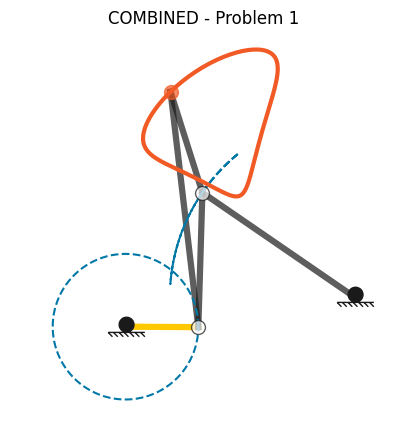

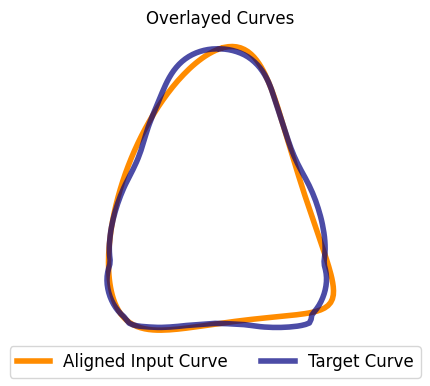

COMBINED, Problem 2: distance=0.739176, material=4.0215, joints=5, links=5


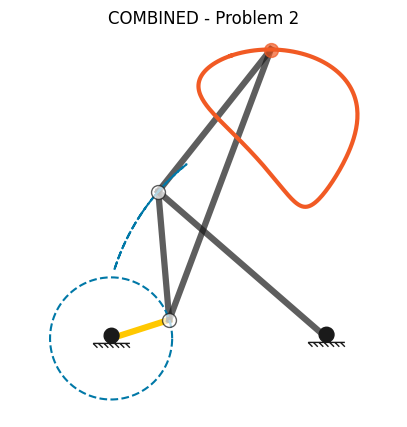

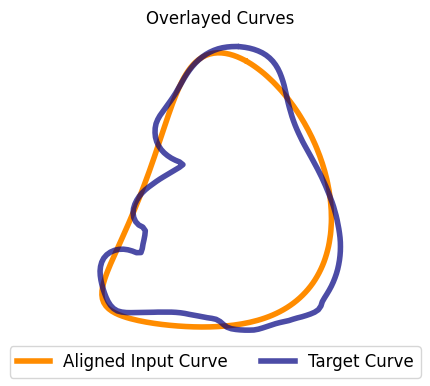

COMBINED, Problem 3: distance=1.01319, material=4.94319, joints=5, links=5


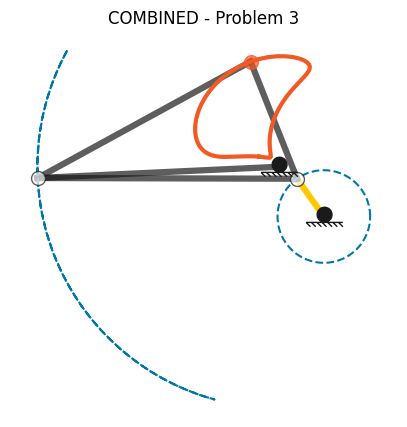

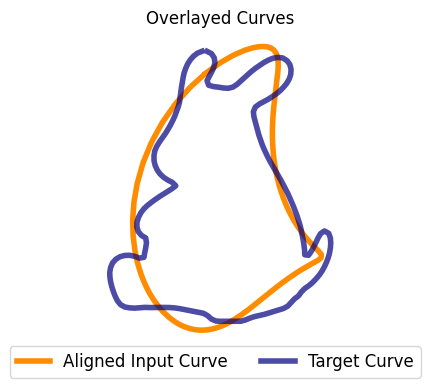

In [64]:
# Only plots of optimized results; rerun this cell without repeating optimization.
if SHOW_FINAL_CURVE:
    visualizer = MechanismVisualizer()
    curve_engine = CurveEngine(resolution=PROBLEM_TOOLS.timesteps, normalize_scale=False)
    for algorithm_name, target_records in [('COMBINED', selected_records['COMBINED'])]:
        for target_index, records in target_records.items():
            if not records:
                print(f'{algorithm_name}, Problem {target_index + 1}: no feasible designs to plot.')
                continue
            best = min(records, key=lambda r: r['F'][0])
            mech = best['mech']
            print(f"{algorithm_name}, Problem {target_index + 1}: "
                  f"distance={best['F'][0]:.6g}, material={best['F'][1]:.6g}, "
                  f"joints={len(mech['x0'])}, links={len(mech['edges'])}")
            fig, ax = plt.subplots(figsize=(5, 5))
            visualizer(mech['x0'], mech['edges'], mech['fixed_joints'], mech['motor'],
                       highlight=mech['target_joint'], ax=ax)
            ax.set_title(f'{algorithm_name} - Problem {target_index + 1}')
            plt.show()
            solutions = np.asarray(PROBLEM_TOOLS.solver(
                [mech['x0']], [mech['edges']], [mech['fixed_joints']], [mech['motor']],
            ))
            traced_curve = solutions[0, mech['target_joint']]
            with jax.disable_jit():
                curve_engine.visualize_comparison(traced_curve, np.asarray(target_curves[target_index]))
            plt.show()